# Mantis: Lightweight Foundation Model for Time Series Classification

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tslearn.datasets import UCR_UEA_datasets

import warnings
from scipy.linalg import LinAlgWarning
warnings.filterwarnings(action='ignore', category=LinAlgWarning)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Data

In [2]:
ds = UCR_UEA_datasets()
X_train, y_train_raw, X_test, y_test_raw = ds.load_dataset('LSST')

# tslearn returns string labels — encode to contiguous integers
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)
N_CLASSES = len(le.classes_)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Classes ({N_CLASSES}): {le.classes_}')

X_train: (2459, 36, 6)  y_train: (2459,)
X_test:  (2466, 36, 6)   y_test:  (2466,)
Classes (14): ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']


In [3]:
# mask of samples where NO band is all-zero
valid_mask = ~(X_train == 0).all(axis=1).any(axis=1)
print(f'{valid_mask.sum()} valid samples out of {len(X_train)}')

valid_mask = ~(X_test == 0).all(axis=1).any(axis=1)
print(f'{valid_mask.sum()} valid samples out of {len(X_test)}')

X_test = X_test[valid_mask]
y_test = y_test[valid_mask]

print(f'X_test: {X_test.shape}  y_test: {y_test.shape}')

2459 valid samples out of 2459
2465 valid samples out of 2466
X_test: (2465, 36, 6)  y_test: (2465,)


## 3. Dataset & DataLoaders

To apply the foundation model `Mantis` to the data, X_train and X_test should be of the shape `(n_samples, n_channels=1, seq_len)`, where `seq_len` is a multiple of 32.

In [4]:
def resize(X):
    X_scaled = F.interpolate(torch.tensor(X, dtype=torch.float), size=64, mode='linear', align_corners=False)
    return X_scaled.numpy()

def pad(X):
    return np.pad(X,((0, 0),(0, 0),(0,28)))

X_train, X_test = X_train.transpose(0, 2, 1), X_test.transpose(0, 2, 1)
X_train, X_test = pad(X_train), pad(X_test)

print("X_train dims: ", X_train.shape)
print("X_test dims: ", X_test.shape)

X_train dims:  (2459, 6, 64)
X_test dims:  (2465, 6, 64)


## 4. Utilities

In [5]:
COLORS = [
    "#ca1b46",'#3cb44b','#ffe119','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#fabed4','#469990','#dcbeff',
    '#9A6324','#fffac8'
]

results  = {}   # name → {macro_f1, acc}
all_preds = {}  # name → predicted labels on test set


def record(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    print(f'{name:45s}  macro-F1={macro_f1:.4f}  acc={acc:.4f}')
    results[name]   = {'macro_f1': macro_f1, 'acc': acc}
    all_preds[name] = y_pred
    return macro_f1, acc

## 5. Load Model

In [6]:
from mantis.architecture import Mantis8M
    
network = Mantis8M(device=DEVICE) # init model
network = network.from_pretrained("paris-noah/MantisPlus") # load weights

### A. Raw embeddings

In [7]:
from mantis.trainer import MantisTrainer

model = MantisTrainer(device=DEVICE, network=network) # init trainer
Z_train = model.transform(X_train)
Z_test = model.transform(X_test)

print("Z_train dims: ", Z_train.shape)
print("Z_test dims: ", Z_test.shape)

Z_train dims:  (2459, 1536)
Z_test dims:  (2465, 1536)


#### Statistical Classifiers

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
Z_train = scaler.fit_transform(Z_train)
Z_test = scaler.transform(Z_test)

In [9]:
ridge_probe = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    scoring='f1_macro',
    cv=cv,
    class_weight='balanced'
)
ridge_probe.fit(Z_train, y_train)
_, _ = record('RidgeClassifierCV [full]', y_test, ridge_probe.predict(Z_test))

RidgeClassifierCV [full]                       macro-F1=0.4914  acc=0.4917


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=8,
    refit=True,
)

rf_grid.fit(Z_train, y_train)
_, _ = record('RandomForestClassifier [full]', y_test, rf_grid.predict(Z_test))

RandomForestClassifier [full]                  macro-F1=0.4820  acc=0.5708


In [11]:
lr = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 10),
    cv=cv,
    scoring='f1_macro',
    max_iter=5_000,
    class_weight='balanced',
    n_jobs=8,
    refit=True,
    random_state=42,
    use_legacy_attributes=False
)

lr.fit(Z_train, y_train)
_ = record('LogisticRegressionCV [full]', y_test, lr.predict(Z_test))

/sc/home/nemesio.navarro/miniconda3/envs/dlts/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(


LogisticRegressionCV [full]                    macro-F1=0.5485  acc=0.6065


### B. Reduce channel dimension (passbands)

In [12]:
from mantis.adapters import MultichannelProjector

adapter = MultichannelProjector(new_num_channels=3, patch_window_size=1, base_projector='pca')
adapter.fit(X_train)
X_reduced_train, X_reduced_test = adapter.transform(X_train), adapter.transform(X_test)

print("X_reduced_train dims: ", X_reduced_train.shape)
print("X_reduced_test dims: ", X_reduced_test.shape)

X_reduced_train dims:  (2459, 3, 64)
X_reduced_test dims:  (2465, 3, 64)


In [13]:
Z_train = model.transform(X_reduced_train)
Z_test = model.transform(X_reduced_test)

print("Z_train dims: ", Z_train.shape)
print("Z_test dims: ", Z_test.shape)

Z_train dims:  (2459, 768)
Z_test dims:  (2465, 768)


#### Statistical Classifiers

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
Z_train = scaler.fit_transform(Z_train)
Z_test = scaler.transform(Z_test)

In [15]:
ridge_probe = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    scoring='f1_macro',
    cv=cv,
    class_weight='balanced'
)
ridge_probe.fit(Z_train, y_train)
_, _ = record('RidgeClassifierCV [reduced]', y_test, ridge_probe.predict(Z_test))

RidgeClassifierCV [reduced]                    macro-F1=0.4237  acc=0.4256


In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=8,
    refit=True,
)

rf_grid.fit(Z_train, y_train)
_ = record('RandomForestClassifier [reduced]', y_test, rf_grid.predict(Z_test))

RandomForestClassifier [reduced]               macro-F1=0.4535  acc=0.5355


In [17]:
lr = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 10),
    cv=cv,
    scoring='f1_macro',
    max_iter=5_000,
    class_weight='balanced',
    n_jobs=8,
    refit=True,
    random_state=42,
    use_legacy_attributes=False
)

lr.fit(Z_train, y_train)
_ = record('LogisticRegressionCV [reduced]', y_test, lr.predict(Z_test))

/sc/home/nemesio.navarro/miniconda3/envs/dlts/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(


LogisticRegressionCV [reduced]                 macro-F1=0.4655  acc=0.4961


### C. Linear probing

In [18]:
from mantis.trainer import MantisTrainer

model = MantisTrainer(device=DEVICE, network=network)

# initialize some training parameters
def init_optimizer(params): return torch.optim.AdamW(
    params, lr=2e-4, betas=(0.9, 0.999), weight_decay=0.05)

def class_weights_tensor():
    """Balanced class weights as a GPU tensor for CrossEntropyLoss."""
    w = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_train)
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor())

In [19]:
fine_tuning_type = 'head'

# fine-tune the model
model.fit(
    X_train,
    y_train,
    num_epochs=10,
    fine_tuning_type=fine_tuning_type,
    init_optimizer=init_optimizer,
    criterion=criterion
)

_, _ = record('Linear probing', y_test, model.predict(X_test))

Epoch 9: Train Loss 1.6284: 100%|██████████| 10/10 [00:00<00:00, 20.17it/s]


Linear probing                                 macro-F1=0.3987  acc=0.3663


### D. Fine-tuning

In [20]:
fine_tuning_type = 'full'

# don't forget to re-initialize the model before fine-tuning with a different type
model.network = model.network.from_pretrained("paris-noah/MantisPlus")

# fine-tune the model
model.fit(
    X_train,
    y_train,
    num_epochs=10,
    fine_tuning_type=fine_tuning_type,
    init_optimizer=init_optimizer,
    criterion=criterion
)

# predict labels
_, _ = record('Fine-tuning', y_test, model.predict(X_test))

Epoch 9: Train Loss 0.9435: 100%|██████████| 10/10 [00:32<00:00,  3.27s/it]


Fine-tuning                                    macro-F1=0.4852  acc=0.4365


## Results Summary

In [21]:
df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Strategy'})
df = df.sort_values('macro_f1', ascending=False)
print(df.to_string(index=False))

                        Strategy  macro_f1      acc
     LogisticRegressionCV [full]  0.548505 0.606491
        RidgeClassifierCV [full]  0.491366 0.491684
                     Fine-tuning  0.485212 0.436511
   RandomForestClassifier [full]  0.482050 0.570791
  LogisticRegressionCV [reduced]  0.465514 0.496146
RandomForestClassifier [reduced]  0.453531 0.535497
     RidgeClassifierCV [reduced]  0.423655 0.425558
                  Linear probing  0.398669 0.366329


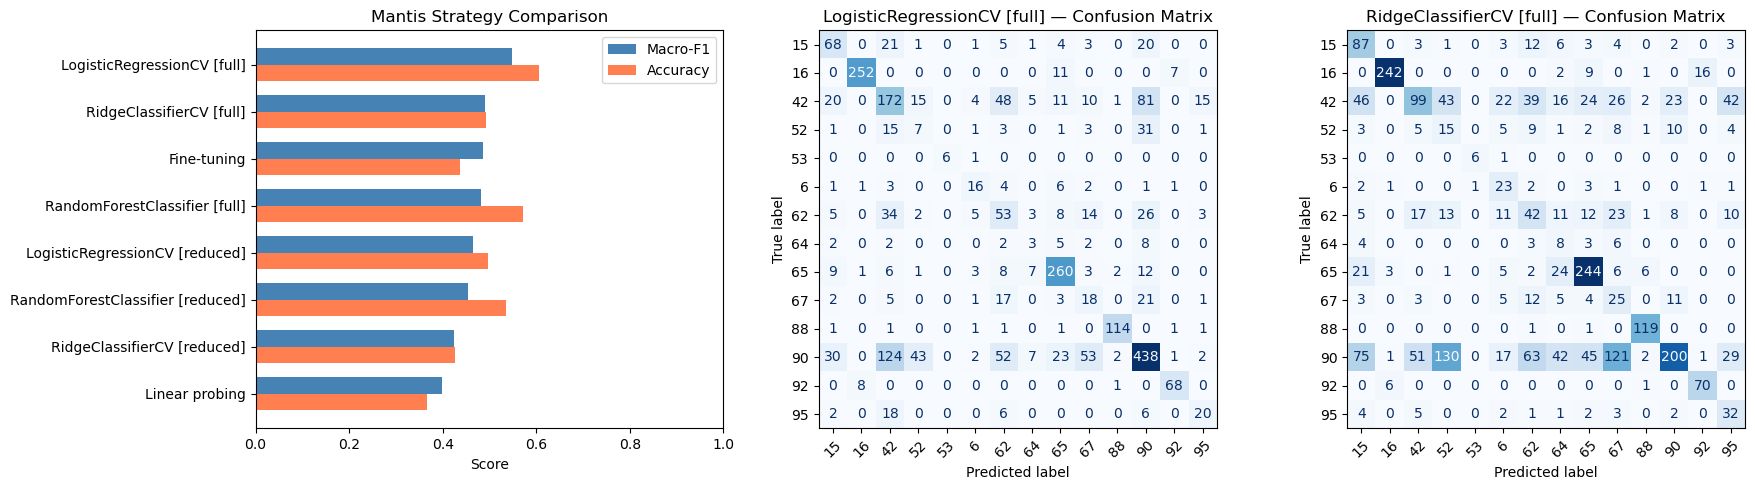

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Horizontal bar chart ───────────────────────────────────────────────────────
names  = df['Strategy'].tolist()
f1s    = df['macro_f1'].tolist()
accs   = df['acc'].tolist()
y      = np.arange(len(names))
height = 0.35

ax = axes[0]
ax.barh(y - height/2, f1s,  height, label='Macro-F1', color='steelblue')
ax.barh(y + height/2, accs, height, label='Accuracy', color='coral')
ax.set_yticks(y)
ax.set_yticklabels([n.split('.')[0] for n in names])
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Mantis Strategy Comparison')
ax.invert_yaxis()
ax.legend()

# ── Confusion matrices (top 2 strategies by macro-F1) ────────────────────────
top2_names = df.sort_values('macro_f1', ascending=False)['Strategy'].head(2).tolist()

for ax, name in zip(axes[1:], top2_names):
    preds = all_preds[name]
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=le.classes_,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(f'{name} — Confusion Matrix')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/mantis_results.png', dpi=150, bbox_inches='tight')
plt.show()